In [1]:
from naive_adc_circuit import naive_circuit
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import generate_preset_pass_manager
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 200

In [2]:
service = QiskitRuntimeService(
    channel='ibm_quantum_platform',
    instance='crn:v1:bluemix:public:quantum-computing:eu-de:a/cb804b30dfcb48b890393bfd6e41e9c2:a59c3379-0cf7-47fe-adf1-553bf24e0c35::'
)

In [3]:
n = [2, 3, 4, 5, 10, 12, 16, 20]
tlist = np.linspace(0, 25, 100)
excited = ["0"]
k = 1
dissipation = True
backend = service.backend("ibm_basquecountry")
pm = generate_preset_pass_manager(optimization_level=3, backend=backend, seed_transpiler=123)

results = {}
virtual_tqds,  isa_tqds= [], []
for size in n:
    J = [1/4]*(size-1)
    gamma = [J[0]/4]*size
    qc = naive_circuit(J, gamma, size, excited, k, dissipation)
    virtual_tqds.append(qc.decompose(reps = 2).depth(lambda instr: len(instr.qubits) > 1))

    isa_qc = pm.run(qc)
    isa_tqds.append(isa_qc.depth(lambda instr: len(instr.qubits) > 1))

    tl = isa_qc.layout
    initial = tl.initial_index_layout(filter_ancillas=True)   # virtual i -> physical, before routing
    final   = tl.final_index_layout(filter_ancillas=True)     # virtual i -> physical, after swaps

    # qubits the ISA circuit actually touches (routing can spill onto ancillas)
    touched = {
        isa_qc.find_bit(q).index
        for inst in isa_qc.data if inst.operation.name not in ("barrier", "delay")
        for q in inst.qubits
    }
    edges = {
        frozenset(isa_qc.find_bit(q).index for q in inst.qubits)
        for inst in isa_qc.data
        if inst.operation.num_qubits == 2 and inst.operation.name not in ("barrier", "delay")
    }

    results[size] = dict(isa=isa_qc, initial=initial, final=final,
                         touched=touched, edges=edges)

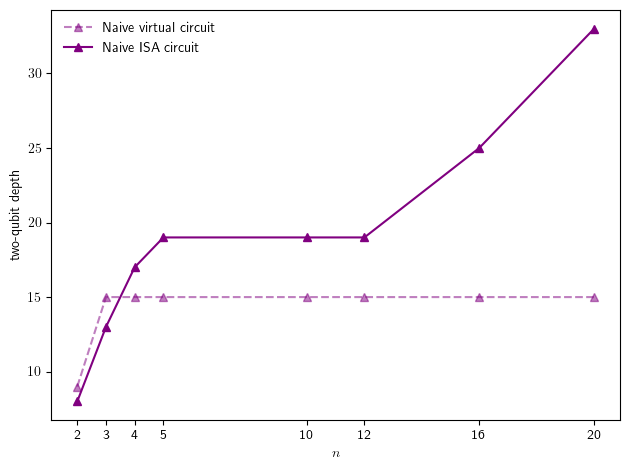

In [5]:
plt.plot(n, virtual_tqds, marker = '^', color = 'purple', linestyle = "dashed", alpha = 0.5, label = 'Naive virtual circuit')
plt.plot(n, isa_tqds, marker = '^', color = 'purple', label = 'Naive ISA circuit')
plt.xlabel("$n$")
plt.ylabel("two-qubit depth")
plt.legend(frameon = False)
plt.xticks(n, n)
plt.tight_layout()
plt.savefig("tqd_scaling_naive_adc.png", bbox_inches='tight', transparent = True)
plt.show()

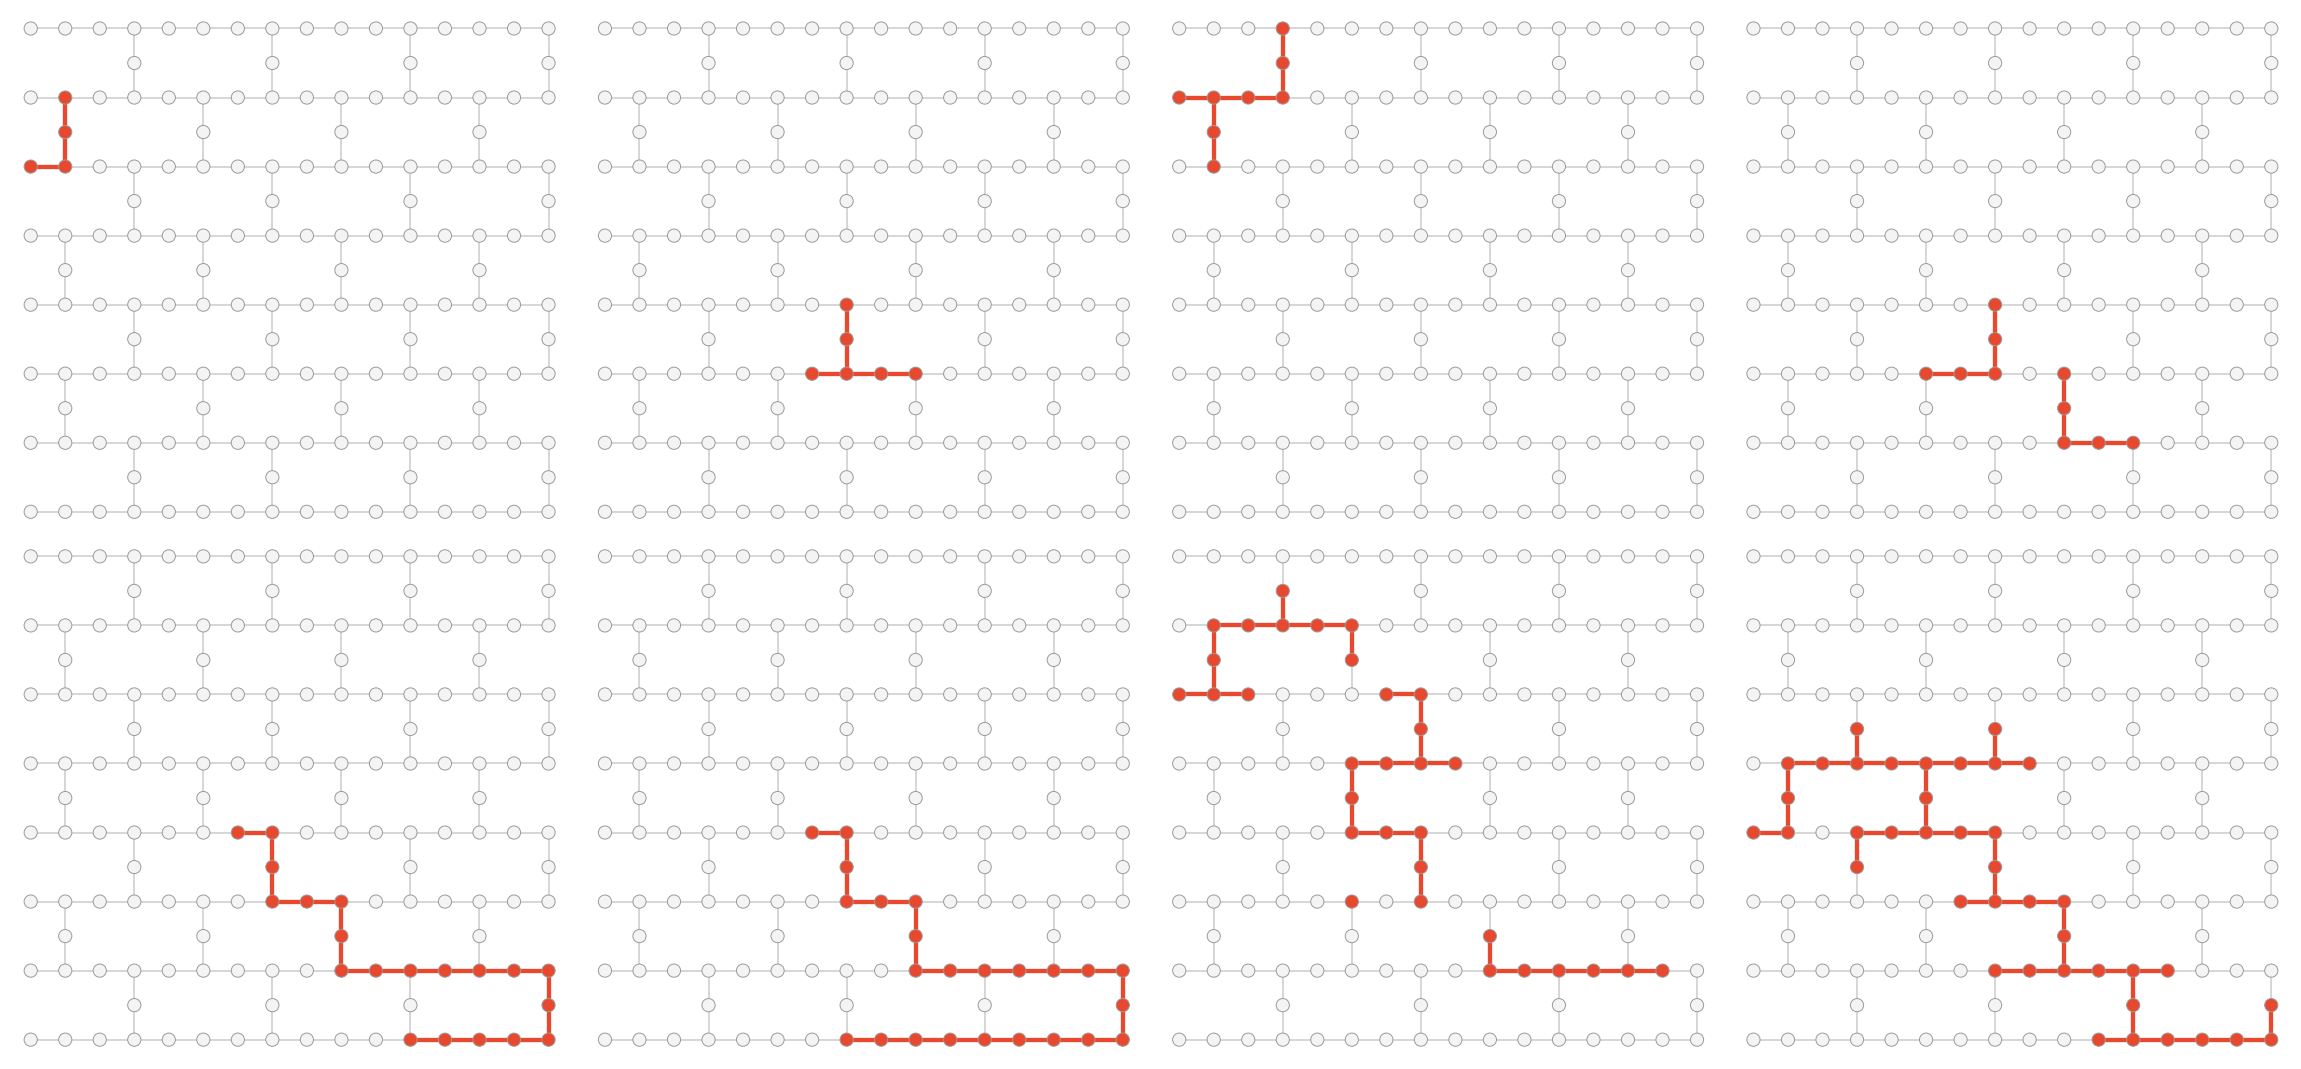

In [8]:
from matplotlib.lines import Line2D
from plot_layout import plot_layout, plot_layouts

# plot_layout(pm.run(qc), backend)                                
fig, axes = plot_layouts([results[s]["isa"] for s in n], backend, which = "initial")  